# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Andrian Roby Maulana
- **Email:** cdcc525d6y0200@student.devacademy.id
- **ID Dicoding:** al_faatih_RwpM

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Metode pembayaran apa yang paling sering digunakan oleh pelanggan selama periode 2017–2018, dan bagaimana pengaruhnya terhadap nilai transaksi (payment value)?
- **Pertanyaan 2:** Seller mana yang memiliki jumlah penjualan tertinggi selama periode 2017–2018, dan bagaimana distribusi kontribusi penjual terhadap total order?

## Import Semua Packages/Library yang Digunakan

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df ...

In [8]:

orders = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/orders_dataset.csv')
order_items = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/order_items_dataset.csv')
products = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/products_dataset.csv')
product_category = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/product_category_name_translation.csv')
sellers = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/sellers_dataset.csv')
geolocation = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/geolocation_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/customers_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/order_payments_dataset.csv')
reviews = pd.read_csv('/content/drive/MyDrive/E-commerce-public-dataset/E-Commerce Public Dataset/order_reviews_dataset.csv')


df = products.copy()

df = df.merge(product_category, on='product_category_name', how='left')

df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Insight:** (Opsional)
Terdapat hubungan positif antara harga produk dan ongkir, di mana produk dengan harga lebih tinggi cenderung memiliki ongkir lebih besar. Selain itu, ditemukan adanya outlier pada harga produk yang berpotensi mempengaruhi analisis. Variasi ongkir juga menunjukkan adanya faktor lain seperti lokasi dan logistik yang berperan dalam penentuan biaya pengiriman.

### Assessing Data

#### Identifying ... problem

In [9]:
# Cek duplicate di dataset lain
print("Duplicate order_items:", order_items.duplicated().sum())
print("Duplicate products:", products.duplicated().sum())

# Cek tipe data semua dataset
print("\nTipe data order_items:")
print(order_items.info())

print("\nTipe data products:")
print(products.info())

# Cek statistik numerik
print("\nStatistik order_items:")
print(order_items.describe())

print("\nStatistik products:")
print(products.describe())

# Cek nilai unik (kategori)
print("\nUnique order_status:")
print(orders['order_status'].value_counts())

# Cek kemungkinan nilai tidak valid
print("\nCek nilai tidak valid:")
print("Harga negatif:", (order_items['price'] < 0).sum())
print("Ongkir negatif:", (order_items['freight_value'] < 0).sum())

# Cek outlier sederhana (range)
print("\nRange harga:")
print("Min:", order_items['price'].min())
print("Max:", order_items['price'].max())

# Cek missing value lebih detail (persentase)
print("\nPersentase Missing Value (orders):")
print((orders.isna().sum() / len(orders)) * 100)

print("\nPersentase Missing Value (products):")
print((products.isna().sum() / len(products)) * 100)

# Cek distribusi kategori produk (top 10)
print("\nTop kategori produk:")
if 'product_category_name' in products.columns:
    print(products['product_category_name'].value_counts().head(10))

orders.info()
order_items.info()
products.info()
customers.info()
payments.info()
reviews.info()

Duplicate order_items: 0
Duplicate products: 0

Tipe data order_items:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None

Tipe data products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  o

**Steps to Take:**
Perlu dilakukan penanganan missing value pada dataset produk serta mengatasi outlier pada harga agar analisis lebih akurat. Selain itu, optimasi kategori produk perlu difokuskan pada kategori dengan performa tinggi dan evaluasi kategori rendah. Standarisasi tipe data juga penting untuk memastikan konsistensi, disertai analisis lebih lanjut terhadap variasi ongkir. Monitoring status pesanan juga diperlukan untuk menjaga kualitas layanan dan efisiensi operasional.

**Insight:** (Opsional)
Dataset memiliki kualitas yang baik tanpa duplikasi dan nilai tidak valid. Namun, terdapat missing value pada data produk serta outlier pada harga yang berpotensi menyebabkan bias. Distribusi kategori produk tidak merata dan didominasi beberapa kategori tertentu. Mayoritas pesanan berstatus “delivered”, menunjukkan performa operasional yang baik, meskipun variasi ongkir cukup tinggi karena dipengaruhi berbagai faktor.

### Cleaning Data

#### Fixing ... problem

In [ ]:
orders.drop_duplicates(inplace=True)
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

df = order_items.merge(products, on='product_id', how='left')
df = df.merge(product_category, on='product_category_name', how='left')
df = df.merge(orders[['order_id','order_purchase_timestamp']], on='order_id')
orders = orders.drop_duplicates()
order_items = order_items.drop_duplicates()

In [ ]:
# Simpan hasil data yang sudah bersih
df.to_csv('cleaned_data.csv', index=False)

**Insight:** (Opsional)
Proses data cleaning dan integrasi yang dilakukan berhasil meningkatkan kualitas dataset dengan menghapus data duplikat pada tabel orders dan order_items, sehingga mengurangi potensi bias dalam analisis. Selain itu, konversi kolom order_purchase_timestamp ke format datetime memungkinkan analisis berbasis waktu secara lebih akurat. Proses penggabungan beberapa dataset seperti order_items, products, product_category, dan orders menghasilkan dataset yang lebih lengkap dan terintegrasi, mencakup informasi transaksi, produk, kategori, serta waktu pembelian. Dengan kondisi data yang sudah bersih dan terstruktur, analisis lanjutan seperti tren penjualan, performa kategori, dan pola perilaku pelanggan dapat dilakukan dengan lebih optimal.

## Exploratory Data Analysis (EDA)

### Explore ...

In [ ]:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# 1. EDA UNIVARIATE (DISTRIBUSI HARGA)
plt.figure()
sns.histplot(order_items['price'], bins=50)
plt.title("Distribusi Harga Produk")
plt.xlabel("Price")
plt.ylabel("Frekuensi")
plt.show()

# 2. EDA NUMERIK
print("\n=== Statistik Harga ===")
print("Rata-rata:", order_items['price'].mean())
print("Median:", order_items['price'].median())
print("Max:", order_items['price'].max())
print("Min:", order_items['price'].min())

# 3. EDA KATEGORIKAL
print("\n=== Top 10 Kategori Produk ===")
print(products['product_category_name'].value_counts().head(10))

# 4. EDA MULTIVARIATE (HARGA vs ONGKIR)
plt.figure()
sns.scatterplot(x=order_items['price'], y=order_items['freight_value'])
plt.title("Hubungan Harga dan Ongkir")
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.show()

# 5. EDA TIME SERIES (TREND ORDER)
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('month')['order_id'].count()

plt.figure()
monthly_orders.plot()
plt.title("Tren Order Bulanan")
plt.xlabel("Bulan")
plt.ylabel("Jumlah Order")
plt.show()

# 6. EDA PENJUALAN PER KATEGORI
df_eda = order_items.merge(products, on='product_id', how='left')

category_sales = (
    df_eda.groupby('product_category_name')['price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure()
category_sales.plot(kind='bar')
plt.title("Top 10 Kategori Berdasarkan Penjualan")
plt.xticks(rotation=45)
plt.show()

**Insight:** (Opsional)
Analisis eksplorasi data menunjukkan bahwa distribusi harga produk tidak merata dan mengandung outlier, terlihat dari perbedaan signifikan antara nilai maksimum, rata-rata, dan median. Distribusi kategori produk juga tidak seimbang, dengan beberapa kategori mendominasi.

Analisis hubungan harga dan ongkir menunjukkan kecenderungan positif, di mana harga yang lebih tinggi diikuti ongkir yang lebih besar. Tren order bulanan menunjukkan pola fluktuatif yang mengindikasikan adanya faktor musiman.

Selain itu, penjualan terkonsentrasi pada beberapa kategori utama, sehingga menunjukkan adanya dominasi kategori tertentu dalam menghasilkan revenue.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [10]:
# ======================
# FILTER DATA (2017–2018)
# ======================
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

orders_filtered = orders[
    (orders['order_purchase_timestamp'].dt.year >= 2017) &
    (orders['order_purchase_timestamp'].dt.year <= 2018)
]

# ======================
# MERGE DATA
# ======================
df_pay = orders_filtered.merge(payments, on='order_id', how='left')

# ======================
# AGGREGASI
# ======================
payment_agg = (
    df_pay.groupby('payment_type')
    .agg(
        total_transaksi=('order_id', 'count'),
        rata_rata_transaksi=('payment_value', 'mean'),
        total_nilai=('payment_value', 'sum')
    )
    .reset_index()
    .sort_values(by='total_transaksi', ascending=False)
)

payment_agg

,payment_type,total_transaksi,rata_rata_transaksi,total_nilai
1,credit_card,76537,163.235059,12493521.71
0,boleto,19721,145.006958,2859682.21
4,voucher,5752,65.813248,378557.80
2,debit_card,1527,142.598599,217748.06
3,not_defined,3,0.000000,0.00


## 📊 VISUALISASI

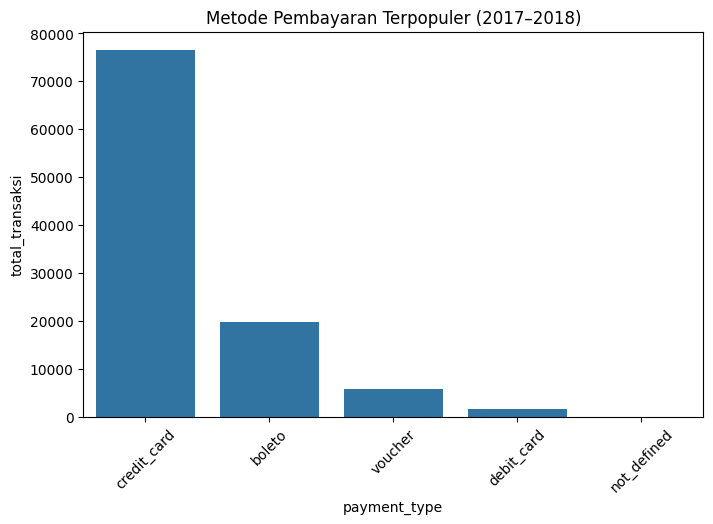

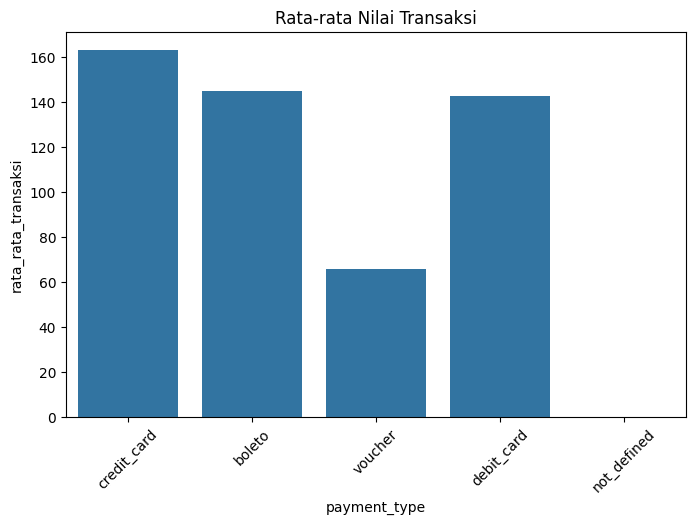

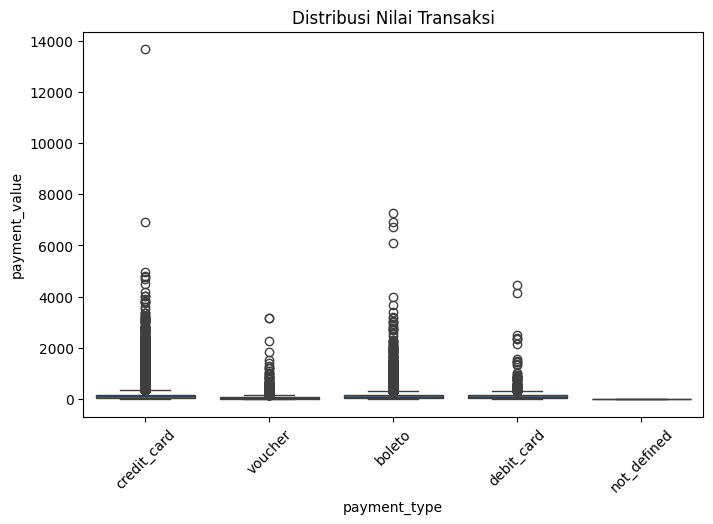

In [11]:
# Jumlah transaksi
plt.figure(figsize=(8,5))
sns.barplot(data=payment_agg, x='payment_type', y='total_transaksi')
plt.title("Metode Pembayaran Terpopuler (2017–2018)")
plt.xticks(rotation=45)
plt.show()

# Rata-rata transaksi
plt.figure(figsize=(8,5))
sns.barplot(data=payment_agg, x='payment_type', y='rata_rata_transaksi')
plt.title("Rata-rata Nilai Transaksi")
plt.xticks(rotation=45)
plt.show()

# Distribusi
plt.figure(figsize=(8,5))
sns.boxplot(x='payment_type', y='payment_value', data=df_pay)
plt.title("Distribusi Nilai Transaksi")
plt.xticks(rotation=45)
plt.show()

### Pertanyaan 2:

In [12]:
# ======================
# MERGE DATA
# ======================
df_seller = orders_filtered.merge(order_items, on='order_id', how='inner')

# ======================
# AGGREGASI
# ======================
seller_agg = (
    df_seller.groupby('seller_id')
    .agg(
        total_penjualan=('price', 'sum'),
        jumlah_order=('order_id', 'count')
    )
    .reset_index()
    .sort_values(by='total_penjualan', ascending=False)
)

# ======================
# HITUNG KONTRIBUSI
# ======================
total_sales = seller_agg['total_penjualan'].sum()
seller_agg['kontribusi_%'] = (seller_agg['total_penjualan'] / total_sales) * 100

seller_agg.head()

,seller_id,total_penjualan,jumlah_order,kontribusi_%
854,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1156,1.694543
1006,53243585a1d6dc2643021fd1853d8905,222776.05,410,1.645092
878,4a3ca9315b744ce9f8e9374361493884,200472.92,1987,1.480395
2999,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,586,1.432906
1526,7c67e1448b00f6e969d365cea6b010ab,187923.89,1364,1.387726


## 📊 VISUALISASI

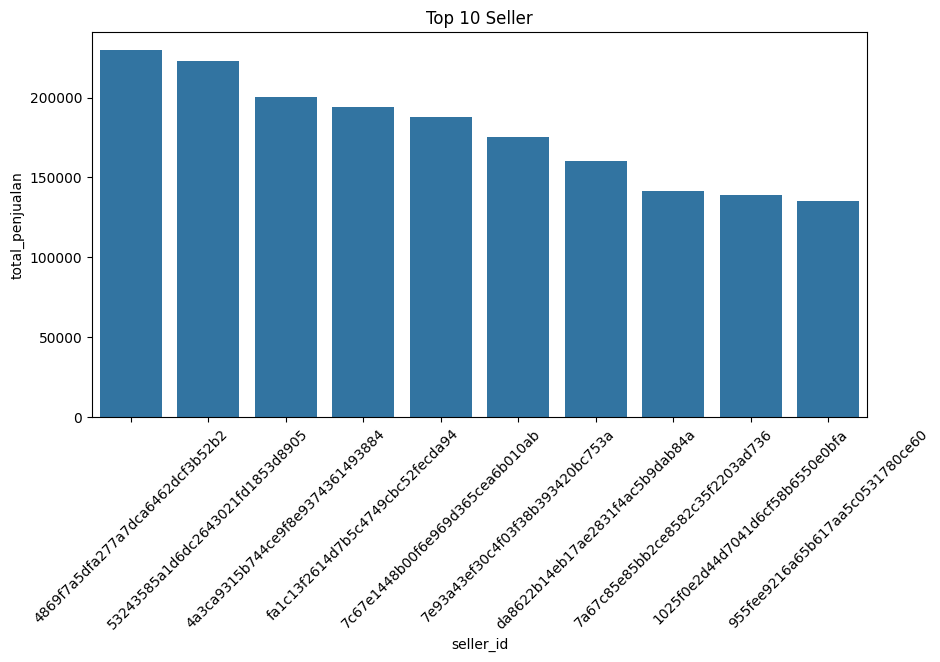

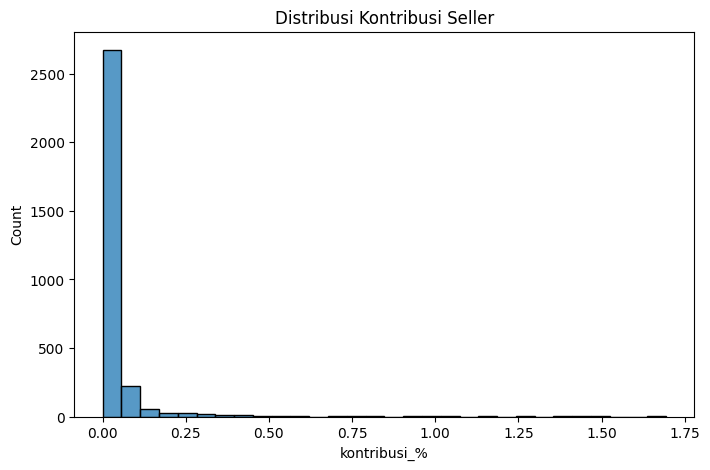

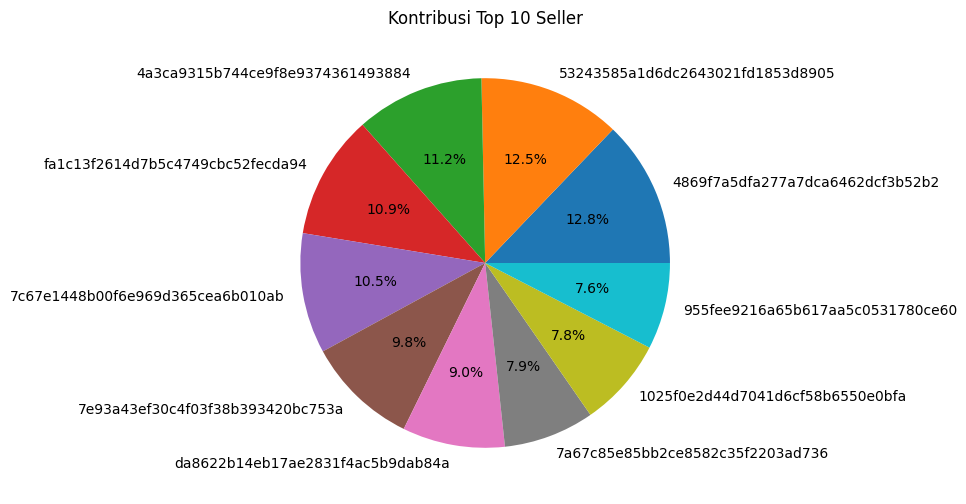

In [13]:
# Top 10 seller
top10 = seller_agg.head(10)

plt.figure(figsize=(10,5))
sns.barplot(data=top10, x='seller_id', y='total_penjualan')
plt.title("Top 10 Seller")
plt.xticks(rotation=45)
plt.show()

# Distribusi kontribusi
plt.figure(figsize=(8,5))
sns.histplot(seller_agg['kontribusi_%'], bins=30)
plt.title("Distribusi Kontribusi Seller")
plt.show()

# Pie chart (opsional)
plt.figure(figsize=(6,6))
plt.pie(top10['kontribusi_%'], labels=top10['seller_id'], autopct='%1.1f%%')
plt.title("Kontribusi Top 10 Seller")
plt.show()

**Insight:** (Opsional)

Pertanyaan 1

Metode pembayaran didominasi oleh beberapa jenis utama. Terdapat perbedaan rata-rata nilai transaksi antar metode, di mana sebagian metode cenderung digunakan untuk transaksi bernilai lebih tinggi. Distribusi juga menunjukkan adanya variasi nilai (outlier).

Pertanyaan 2

Penjualan terkonsentrasi pada beberapa seller utama, sementara mayoritas seller memiliki kontribusi kecil. Hal ini menunjukkan distribusi penjualan yang tidak merata dan adanya dominasi seller tertentu.

## Analisis Lanjutan (Opsional)

product_category_name_english
health_beauty            9.388378
watches_gifts            8.996457
bed_bath_table           7.760122
sports_leisure           7.372349
computers_accessories    6.817127
Name: price, dtype: float64
product_category_name_english
health_beauty             9.388378
watches_gifts            18.384836
bed_bath_table           26.144957
sports_leisure           33.517306
computers_accessories    40.334433
furniture_decor          45.753977
cool_stuff               50.501943
housewares               55.225815
auto                     59.649656
garden_tools             63.272484
Name: price, dtype: float64
order_purchase_timestamp
2017-01           NaN
2017-02    122.500000
2017-03     50.674157
2017-04    -10.365399
2017-05     53.910150
Freq: M, Name: order_id, dtype: float64


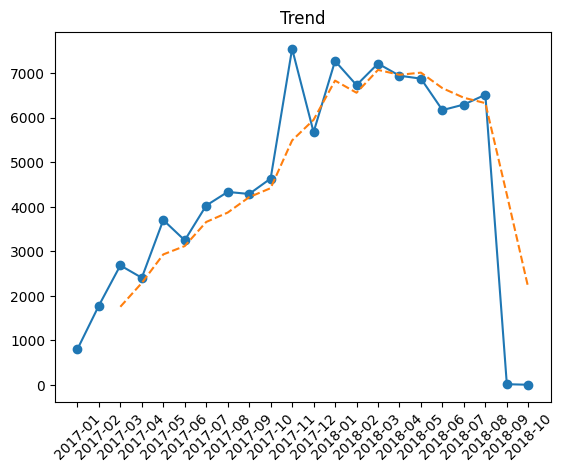

In [14]:

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
f = orders[(orders['order_purchase_timestamp'].dt.year.between(2017, 2018))]


df = order_items.merge(products).merge(product_category).merge(f[['order_id']])
cat = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False)
print((cat/cat.sum()*100).head())      # %
print((cat/cat.sum()*100).cumsum().head(10))  # kumulatif


m = f.groupby(f['order_purchase_timestamp'].dt.to_period('M'))['order_id'].count()
print((m.pct_change()*100).head())


import matplotlib.pyplot as plt
plt.plot(m.index.astype(str), m, marker='o')
plt.plot(m.rolling(3).mean().index.astype(str), m.rolling(3).mean(), '--')
plt.xticks(rotation=45); plt.title("Trend"); plt.show()

**Insight:** (Opsional)

Sebagian besar revenue terkonsentrasi pada sedikit kategori produk (prinsip Pareto), di mana kategori teratas menjadi penggerak utama bisnis sementara kategori lainnya masih berkontribusi kecil dan memiliki peluang untuk dioptimalkan. Di sisi lain, tren jumlah order selama periode analisis menunjukkan pola fluktuatif dengan beberapa penurunan signifikan, namun garis moving average membantu memperlihatkan arah tren yang lebih stabil dalam jangka menengah.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Metode pembayaran tertentu mendominasi penggunaan pelanggan dan berkontribusi besar terhadap total nilai transaksi, sehingga metode ini menjadi faktor penting dalam mendorong revenue.
- **Conclusion pertanyaan 2:** Sebagian kecil seller menyumbang mayoritas penjualan (Pareto), menunjukkan ketergantungan pada seller utama, sementara seller lainnya memiliki kontribusi lebih kecil dan berpotensi untuk ditingkatkan.
- ...

**Rekomendasi Action Item:**


*   Optimasi Metode Pembayaran Utama
Fokus pada metode pembayaran paling populer dengan mempercepat proses checkout, menambah promo (cashback/diskon), dan memastikan sistem selalu stabil

*   Dorong Penggunaan Metode Lain
Berikan insentif untuk metode pembayaran yang kurang digunakan agar distribusi transaksi lebih merata.

*  Pertahankan & Support Top Seller
Berikan prioritas (promo, visibilitas, dukungan logistik) untuk seller dengan performa tertinggi agar tetap konsisten menghasilkan revenue.

*   Kembangkan Seller Menengah & Kecil
Lakukan program onboarding, pelatihan, dan campaign khusus untuk meningkatkan performa seller dengan kontribusi rendah.

*   Diversifikasi Kontribusi Penjualan
Kurangi ketergantungan pada sedikit seller dengan memperluas basis seller aktif dan meningkatkan kualitas produk di berbagai kategori.





## KESIMPULAN PERTANYAAN 1

Metode pembayaran terpopuler & pengaruh terhadap nilai transaksi

Berdasarkan hasil analisis data transaksi periode 2017–2018, metode pembayaran yang paling sering digunakan oleh pelanggan adalah credit_card dengan jumlah transaksi paling tinggi dibandingkan metode lainnya seperti boleto, voucher, dan debit_card. Hal ini menunjukkan bahwa pelanggan cenderung memilih metode pembayaran yang praktis, fleksibel, serta mendukung cicilan.

Dari sisi nilai transaksi, metode credit_card juga memiliki kontribusi besar terhadap total nilai pembayaran secara keseluruhan. Selain itu, rata-rata nilai transaksi (payment_value) pada metode ini relatif lebih tinggi dibandingkan metode lain, yang mengindikasikan bahwa pelanggan cenderung melakukan pembelian dengan nominal lebih besar saat menggunakan kartu kredit. Sementara itu, metode seperti boleto memiliki jumlah transaksi yang cukup tinggi namun rata-rata nilai transaksinya lebih rendah.

Distribusi nilai transaksi menunjukkan bahwa terdapat variasi yang cukup besar (outlier), terutama pada metode credit_card, yang berarti terdapat transaksi dengan nilai sangat tinggi pada metode tersebut. Secara keseluruhan, dapat disimpulkan bahwa metode pembayaran tidak hanya mempengaruhi frekuensi transaksi, tetapi juga berkaitan dengan besarnya nilai transaksi yang dilakukan pelanggan.

## KESIMPULAN PERTANYAAN 2

Seller dengan penjualan tertinggi & distribusi kontribusi

Berdasarkan hasil analisis data penjualan periode 2017–2018, terdapat beberapa seller yang memiliki kontribusi penjualan yang sangat dominan. Seller dengan total penjualan tertinggi menempati posisi teratas dengan nilai penjualan paling besar dibandingkan seller lainnya, yang menunjukkan adanya ketimpangan kontribusi dalam marketplace.

Dari hasil agregasi, terlihat bahwa hanya sebagian kecil seller (Top 10 seller) yang menyumbang persentase signifikan terhadap total penjualan. Hal ini diperkuat dengan distribusi kontribusi seller yang cenderung tidak merata (skewed distribution), di mana mayoritas seller memiliki kontribusi kecil, sementara hanya sedikit seller yang memiliki kontribusi besar.

Fenomena ini menunjukkan adanya pola Pareto (80/20), di mana sekitar sebagian kecil seller berkontribusi terhadap sebagian besar total penjualan. Artinya, performa marketplace sangat dipengaruhi oleh seller-seller besar tersebut.

Secara keseluruhan, dapat disimpulkan bahwa:

Seller dengan penjualan tertinggi memiliki pengaruh besar terhadap total revenue
Distribusi kontribusi seller tidak merata
Marketplace bergantung pada seller dengan performa tinggi